In [1]:
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import numpy as np
from project1 import parse
from eval import Energy, Energy_coords, Force, Force_coords, GD, atoms_to_coord
from atom import Atom, print_atoms

# GD 2.in Sample Input

In [2]:
input = 'test_input/GD/2.in'
config, atoms = parse(input)

In [3]:
print(f'configurations: {config}')
print(f'list of Atom objects: {atoms}')
print('Initial Atom coordinates: ')
print(print_atoms(atoms))

configurations: {'JOB': 'GD', 'VERBOSE': 'True'}
list of Atom objects: [<atom.Atom object at 0x111e04980>, <atom.Atom object at 0x111b3ec10>]
Initial Atom coordinates: 
    Ar 0.0 0.0 0.0
    Ar 4.0 0.0 0.0



In [4]:
coords = atoms_to_coord(atoms)

E_atoms = Energy(atoms)
E_coords = Energy_coords(coords)

F_atoms = Force(atoms)
F_coords = Force_coords(coords)

print(f'Initial Coordinates: \n{coords}\n')

print(f'Energy from Atoms: {E_atoms}')
print(f'Energy from Coordinates: {E_coords}\n')

print(f'Force from Atoms: \n{F_atoms}')
print(f'Force from Coordinates: \n{F_coords}')

Initial Coordinates: 
[[0. 0. 0.]
 [4. 0. 0.]]

Energy from Atoms: -0.9377517718874008
Energy from Coordinates: -0.9377517718874008

Force from Atoms: 
[[ 0.55488402 -0.55488402]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Force from Coordinates: 
[[ 0.55488402 -0.55488402]
 [ 0.          0.        ]
 [ 0.          0.        ]]


In [5]:
initial_stepsize = 0.3
tolerance = 1e-2

atoms_opt, E_opt, iterations = GD(atoms, initial_stepsize, tolerance, verbose=config['VERBOSE']) # gradient descent call (VERBOSE: True)


Initial coordinates: 
    Ar 0.0 0.0 0.0
    Ar 4.0 0.0 0.0
 
Initial energy: -9.378e-01 kJ/mol
Initial Force: 
[[ 0.55488402  0.          0.        ]
 [-0.55488402  0.          0.        ]]
Initial stepsize: 0.3 
Threshold for convergence: 0.01 

    
Iteration 0: 
New Step Rejected, reducing stepsize... 
Current stepsize: 0.15
New coordinates: 
    Ar 0.21213203435596426 0.0 0.0
    Ar 3.7878679656440357 0.0 0.0

New Force: 
[[ 0.55488402  0.          0.        ]
 [-0.55488402  0.          0.        ]]
New energy: -0.9377517718874008 

        
Iteration 0: 
New Step Rejected, reducing stepsize... 
Current stepsize: 0.15
New coordinates: 
    Ar 0.21213203435596426 0.0 0.0
    Ar 3.7878679656440357 0.0 0.0

New Force: 
[[ 0.55488402  0.          0.        ]
 [-0.55488402  0.          0.        ]]
New energy: -0.9377517718874008 

        Iteration 1: 
New Step Accepted.
Current stepsize: 0.18
New coordinates: 
    Ar 0.10606601717798213 0.0 0.0
    Ar 3.893933982822018 0.0 0.0

New 

In [6]:
print(f'Optimized Coordinates: \n{atoms_to_coord(atoms_opt)}\n')
print(f'Optimized Energy: {E_opt}')
print(f'Total iterations: {iterations}')

Optimized Coordinates: 
[[0.09111071 0.         0.        ]
 [3.90888929 0.         0.        ]]

Optimized Energy: -0.997995124931327
Total iterations: 12


In [7]:
def draw_config_3d(ax, r, box_min, box_max, title, point_size=50):
    ax.clear()

    ax.scatter(r[:, 0], r[:, 1], r[:, 2], s=point_size, alpha=0.6, edgecolors='k')

    ax.set_xlim(-box_min, box_max)
    ax.set_ylim(-box_min, box_max)
    ax.set_zlim(-box_min, box_max)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(title)

    ax.view_init(elev=30, azim=45)


Initial coordinates: 
    Ar 0.0 0.0 0.0
    Ar 4.0 0.0 0.0
 
Initial energy: -9.378e-01 kJ/mol
Initial Force: 
[[ 0.55488402  0.          0.        ]
 [-0.55488402  0.          0.        ]]
Initial stepsize: 0.3 
Threshold for convergence: 0.01 

    


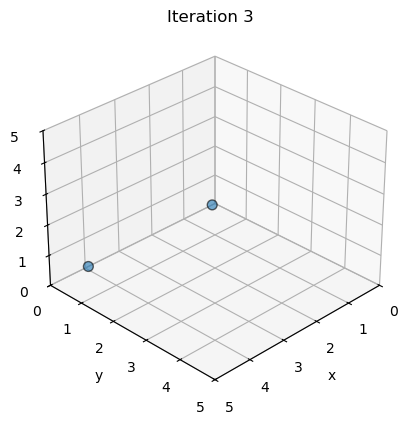

In [ ]:
input = 'test_input/GD/2.in'
config, atoms = parse(input)

# trajectory object is a list of np.arrays with dim (N, 3) of the coordinates
trajectory = GD(atoms, initial_stepsize, tolerance, fname=None, keep_trajectory=True, verbose=False) 


box_min = 0
box_max = 5

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    coord = trajectory[frame]
    title = f"Iteration {frame}"
    draw_config_3d(ax, coord, box_min, box_max, title, point_size=50)

ani = FuncAnimation(fig, update, frames=len(trajectory), interval=500)
ani.save("MD_simumations/2_trajectory.gif", writer="pillow", fps=1)
plt.show()


Initial coordinates: 
    Ar 0.0 -5.0 0.0
    Ar 0.0 5.0 0.0
    Ar -3.6 0.0 0.0
 
Initial energy: -2.253e-01 kJ/mol
Initial Force: 
[[-0.06052883  0.0877565   0.        ]
 [-0.06052883 -0.0877565   0.        ]
 [ 0.12105766  0.          0.        ]]
Initial stepsize: 0.3 
Threshold for convergence: 0.01 

    


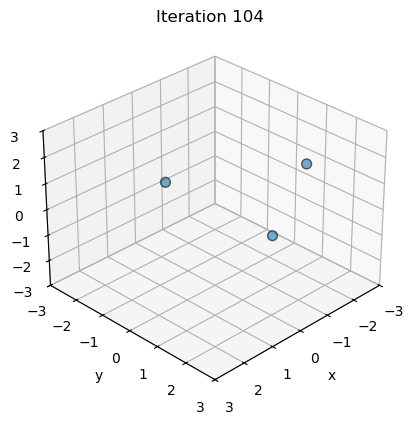

In [9]:
input = 'test_input/GD/3.in'
config, atoms = parse(input)
trajectory = GD(atoms, initial_stepsize, tolerance, fname=None, keep_trajectory=True, verbose=False)

box_min = 3
box_max = 3

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    coord = trajectory[frame]
    title = f"Iteration {frame}"
    draw_config_3d(ax, coord, box_min, box_max, title, point_size=50)

ani = FuncAnimation(fig, update, frames=len(trajectory), interval=500)
ani.save("MD_simumations/3_trajectory.gif", writer="pillow", fps=5)
plt.show()


Initial coordinates: 
    Ar 0.0 -5.0 0.0
    Ar 4.0 0.0 0.0
    Ar 0.0 5.0 0.0
    Ar -3.6 0.0 0.0
    Ar 0.0 0.0 2.0
 
Initial energy: -2.391e+00 kJ/mol
Initial Force: 
[[-0.01049989  0.3787297   0.09137481]
 [-0.69269956  0.          0.28389085]
 [-0.01049989 -0.3787297   0.09137481]
 [ 0.73625036  0.          0.32796263]
 [-0.02255103  0.         -0.7946031 ]]
Initial stepsize: 0.3 
Threshold for convergence: 0.01 

    


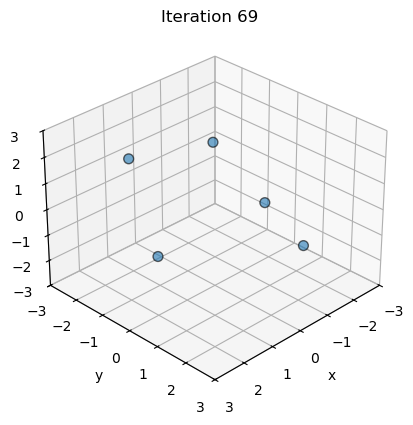

In [10]:
input = 'test_input/GD/5.in'
config, atoms = parse(input)
trajectory = GD(atoms, initial_stepsize, tolerance, fname=None, keep_trajectory=True, verbose=False)

box_min = 3
box_max = 3

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    coord = trajectory[frame]
    title = f"Iteration {frame}"
    draw_config_3d(ax, coord, box_min, box_max, title, point_size=50)

ani = FuncAnimation(fig, update, frames=len(trajectory), interval=500)
ani.save("MD_simumations/5_trajectory.gif", writer="pillow", fps=5)
plt.show()

# Miscellaneous (Constant Evaluations)

In [11]:
e_kb = 120 # K
kb = 1.380649e-23 # J * K^-1
N = 6.022e23 # mol^-1

e = e_kb * kb * N / 1000
e

0.99771219336